# Stationary RF & Throughput Analysis — ICE vs Telenor
### TTM4905 Master Thesis · Anders Furdal Wold · NTNU IIK

**Two parallel SIMs measured simultaneously, stationary location, 4 sessions:**

| Session | Date | Condition |
|---------|------|-----------|
| 04-17 | Apr 17 | Stationary reference |
| 04-20 ant | Apr 20 AM | Antennas switched |
| 04-20 sim | Apr 20 PM | SIMs swapped |
| 04-23 | Apr 23 | 1 modem then 2 modems |

Each session has **one qmicli + one speedtest per operator** (ICE & Telenor).

| SIM | Operator | PLMN | Expected RAT |
|-----|----------|------|--------------|
| ICE | Ice Norway | 24214 | 5G SA (n78) — roams onto Telenor when Ice coverage absent |
| Telenor | Telenor Norway | 24201 | LTE / NSA |

**Key questions:**
- Is ICE roaming on Telenor infrastructure? (stationary ⟹ any cell change = roaming event)
- Who gets better RSRP when both share the same PLMN / cells?
- Does ICE switch cells more often than Telenor?
- How does throughput compare across all 4 sessions?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 18,
    'legend.title_fontsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'axes.grid': True,
    'grid.alpha': 0.35,
})

# ── Palette
C_ICE     = '#1E88E5'
C_TELENOR = '#E53935'
C_5GSA    = '#43A047'
C_NSA     = '#FB8C00'
C_LTE     = '#8E24AA'
C_NAN     = '#9E9E9E'

PLMN_LABEL = {24201.0: 'Telenor (24201)', 24214.0: 'Ice (24214)'}
PLMN_COLOR = {24201.0: C_TELENOR, 24214.0: C_ICE}
RAT_COLOR  = {'lte': C_LTE, 'nsa': C_NSA, '5gsa': C_5GSA}

SESSION_LABEL = {
    '04.17_stationary_test':   '04.17 Stationary',
    '04.20_antennas_switched': '04.20 Ant. Switch',
    '04.20_swapped_sims':      '04.20 SIM Swap',
    '04.23_1modem_then2':      '04.23 1→2 Modems',
}
SESSIONS = list(SESSION_LABEL.keys())

def smooth(arr, w=20):
    if len(arr) < w: return arr
    kernel = np.ones(w) / w
    return np.convolve(arr.astype(float), kernel, mode='same')

def cell_changes(df):
    v = df.dropna(subset=['cell_id'])
    if len(v) < 2: return v.iloc[:0]
    mask = v['cell_id'] != v['cell_id'].shift()
    mask.iloc[0] = False
    return v[mask]

print('Libraries loaded ✓')

Libraries loaded ✓


## Data Loading

In [2]:
BASE = 'usable_datasets/stationary'

def load_qmi(path, operator, session):
    df = pd.read_csv(path, parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)
    df['operator']    = operator
    df['session']     = session
    df['active_plmn'] = df['lte_plmn'].fillna(df['nr_plmn'])
    df['rsrp_active'] = df['nr_rsrp_dbm'].combine_first(df['lte_rsrp_dbm'])
    df['rsrq_active'] = df['nr_rsrq_db'].combine_first(df['lte_rsrq_db'])
    df['cell_id']     = df['lte_ecgi'].combine_first(df['nr_nci'])
    df['pci']         = df['lte_pci'].combine_first(df['nr_pci'])
    df['t_rel']       = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds() / 60.0
    return df

def load_spd(path, operator, session):
    df = pd.read_csv(path, parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)
    df['operator']      = operator
    df['session']       = session
    df['download_mbps'] = df['download'] / 1e6
    df['upload_mbps']   = df['upload']   / 1e6
    df['t_rel']         = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds() / 60.0
    return df

ice_qmi, ice_spd, tel_qmi, tel_spd = {}, {}, {}, {}

for sess in SESSIONS:
    date, suffix = sess.split('_', 1)  # '04.17', 'stationary_test'
    ice_qmi[sess] = load_qmi(f'{BASE}/ice/{date}_qmicli_{suffix}.csv',      'ICE',     sess)
    ice_spd[sess] = load_spd(f'{BASE}/ice/{date}_speedtest_{suffix}.csv',   'ICE',     sess)
    tel_qmi[sess] = load_qmi(f'{BASE}/telenor/{date}_qmicli_{suffix}.csv',  'Telenor', sess)
    tel_spd[sess] = load_spd(f'{BASE}/telenor/{date}_speedtest_{suffix}.csv','Telenor', sess)

for sess in SESSIONS:
    ice_qmi[sess]['is_roaming'] = ice_qmi[sess]['active_plmn'] == 24201.0

print(f"{'Session':<24} {'Op':<8} {'Rows':>6}  {'RSRP mean':>10}  {'Cell Δ':>7}  {'PLMNs seen'}")
print('-' * 78)
for sess in SESSIONS:
    for op, dq in [('ICE', ice_qmi[sess]), ('Telenor', tel_qmi[sess])]:
        chg   = cell_changes(dq)
        plmns = sorted(dq['active_plmn'].dropna().unique().astype(int).tolist())
        print(f"  {SESSION_LABEL[sess]:<22} {op:<8} {len(dq):>6}  "
              f"{dq['rsrp_active'].mean():>9.1f}  {len(chg):>7}  {plmns}")

Session                  Op         Rows   RSRP mean   Cell Δ  PLMNs seen
------------------------------------------------------------------------------
  04.17 Stationary       ICE        1750      -77.2        0  [24201]
  04.17 Stationary       Telenor    1755      -82.4        2  [24201]
  04.20 Ant. Switch      ICE         970      -81.7        9  [24201]
  04.20 Ant. Switch      Telenor    1047      -89.4        0  [24201]
  04.20 SIM Swap         ICE        1999     -102.6        0  [24214]
  04.20 SIM Swap         Telenor    2000      -77.5        0  [24201]
  04.23 1→2 Modems       ICE        2218     -106.8        6  [24214]
  04.23 1→2 Modems       Telenor    1610      -90.8        1  [24201]


## Roaming Detection

The device is **stationary** throughout all sessions — no mobility at all.
Therefore:
- **Telenor SIM**: always on home PLMN 24201, cell changes = antenna/hardware effect only.
- **ICE SIM**: home PLMN 24214. If it registers on 24201 → **roaming on Telenor**.
  Any cell handover while stationary = roaming-driven RAN steering, not mobility.

## Figure 1 — RSRP Time Series: ICE vs Telenor, All 4 Sessions

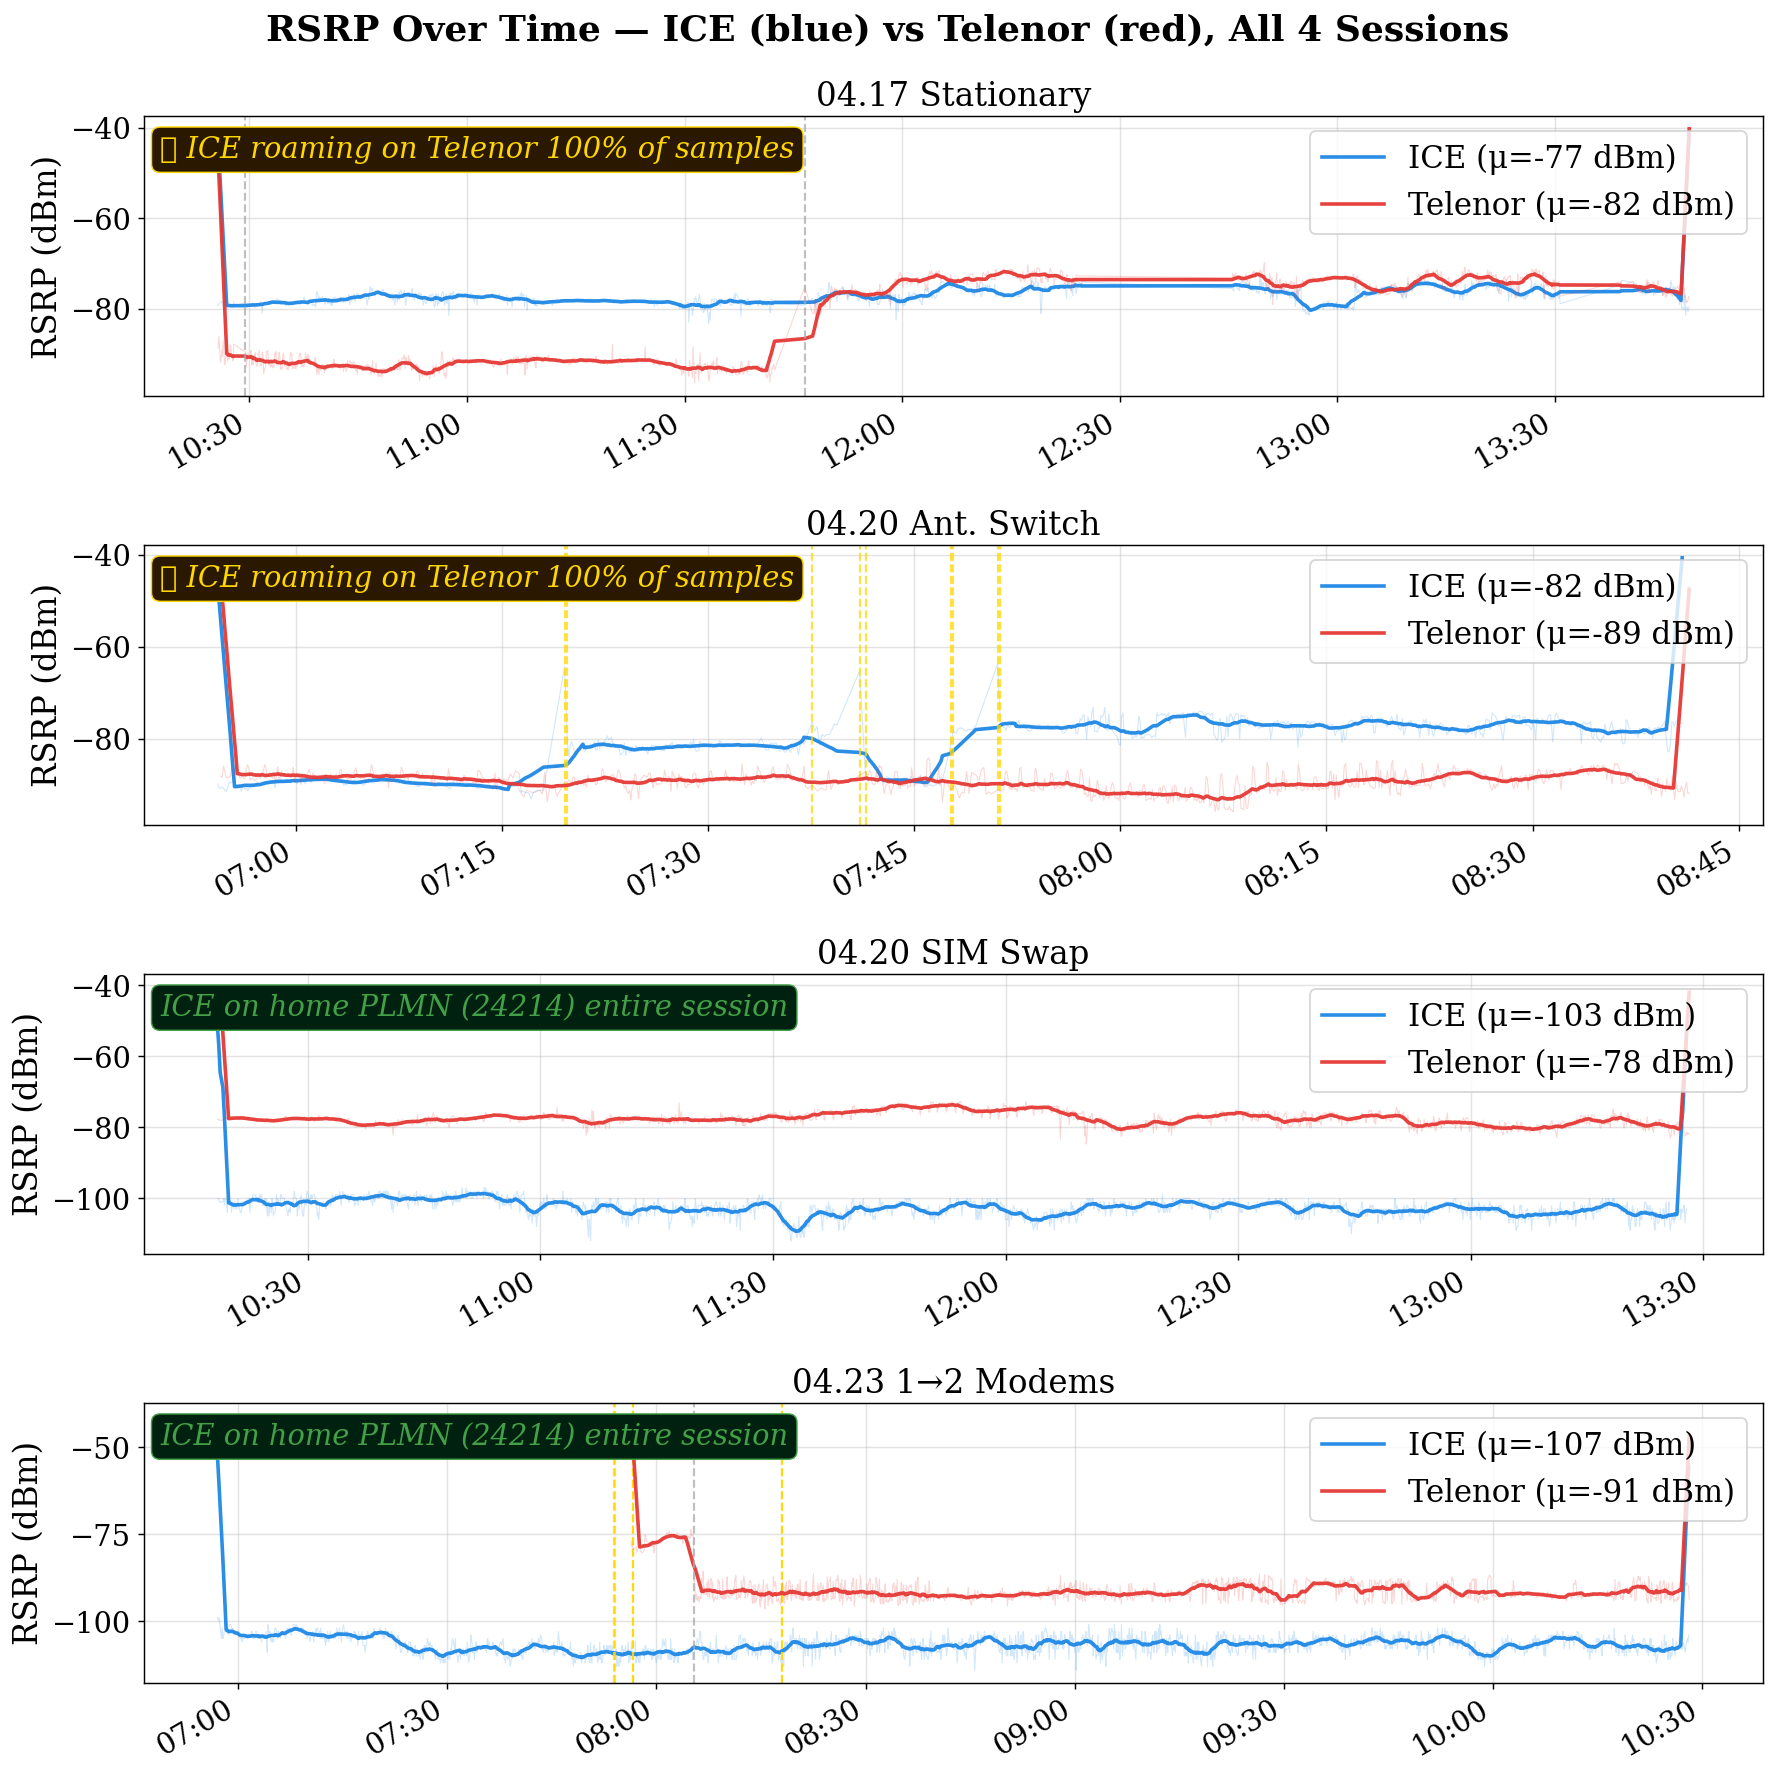

Figure 1 saved.


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)
fig.suptitle('RSRP Over Time — ICE (blue) vs Telenor (red), All 4 Sessions',
             fontsize=20, fontweight='bold')

for ax, sess in zip(axes, SESSIONS):
    for op, dq, color in [('ICE', ice_qmi[sess], C_ICE), ('Telenor', tel_qmi[sess], C_TELENOR)]:
        valid = dq.dropna(subset=['rsrp_active'])
        if valid.empty: continue
        t  = valid['timestamp']
        rs = valid['rsrp_active'].values
        ax.plot(t, rs,          color=color, alpha=0.20, linewidth=0.6)
        ax.plot(t, smooth(rs, 25), color=color, alpha=0.95, linewidth=2.0,
                label=f'{op} (μ={np.nanmean(rs):.0f} dBm)')

        # cell-change markers
        for _, row in cell_changes(dq).iterrows():
            ax.axvline(row['timestamp'], color='gold' if op == 'ICE' else '#aaa',
                       linewidth=1.2, linestyle='--', alpha=0.75)

    # roaming banner
    roam_frac = ice_qmi[sess]['is_roaming'].mean()
    if roam_frac > 0:
        ax.text(0.01, 0.93,
                f'⚠ ICE roaming on Telenor {roam_frac*100:.0f}% of samples',
                transform=ax.transAxes, fontsize=16, color='gold', va='top', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a1800',
                          edgecolor='gold', linewidth=0.8))
    else:
        ax.text(0.01, 0.93, 'ICE on home PLMN (24214) entire session',
                transform=ax.transAxes, fontsize=16, color=C_5GSA, va='top', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#002010',
                          edgecolor=C_5GSA, linewidth=0.8))

    ax.set_ylabel('RSRP (dBm)')
    ax.set_title(SESSION_LABEL[sess], fontsize=18)
    ax.legend(fontsize=17, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig1_rsrp_timeseries.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

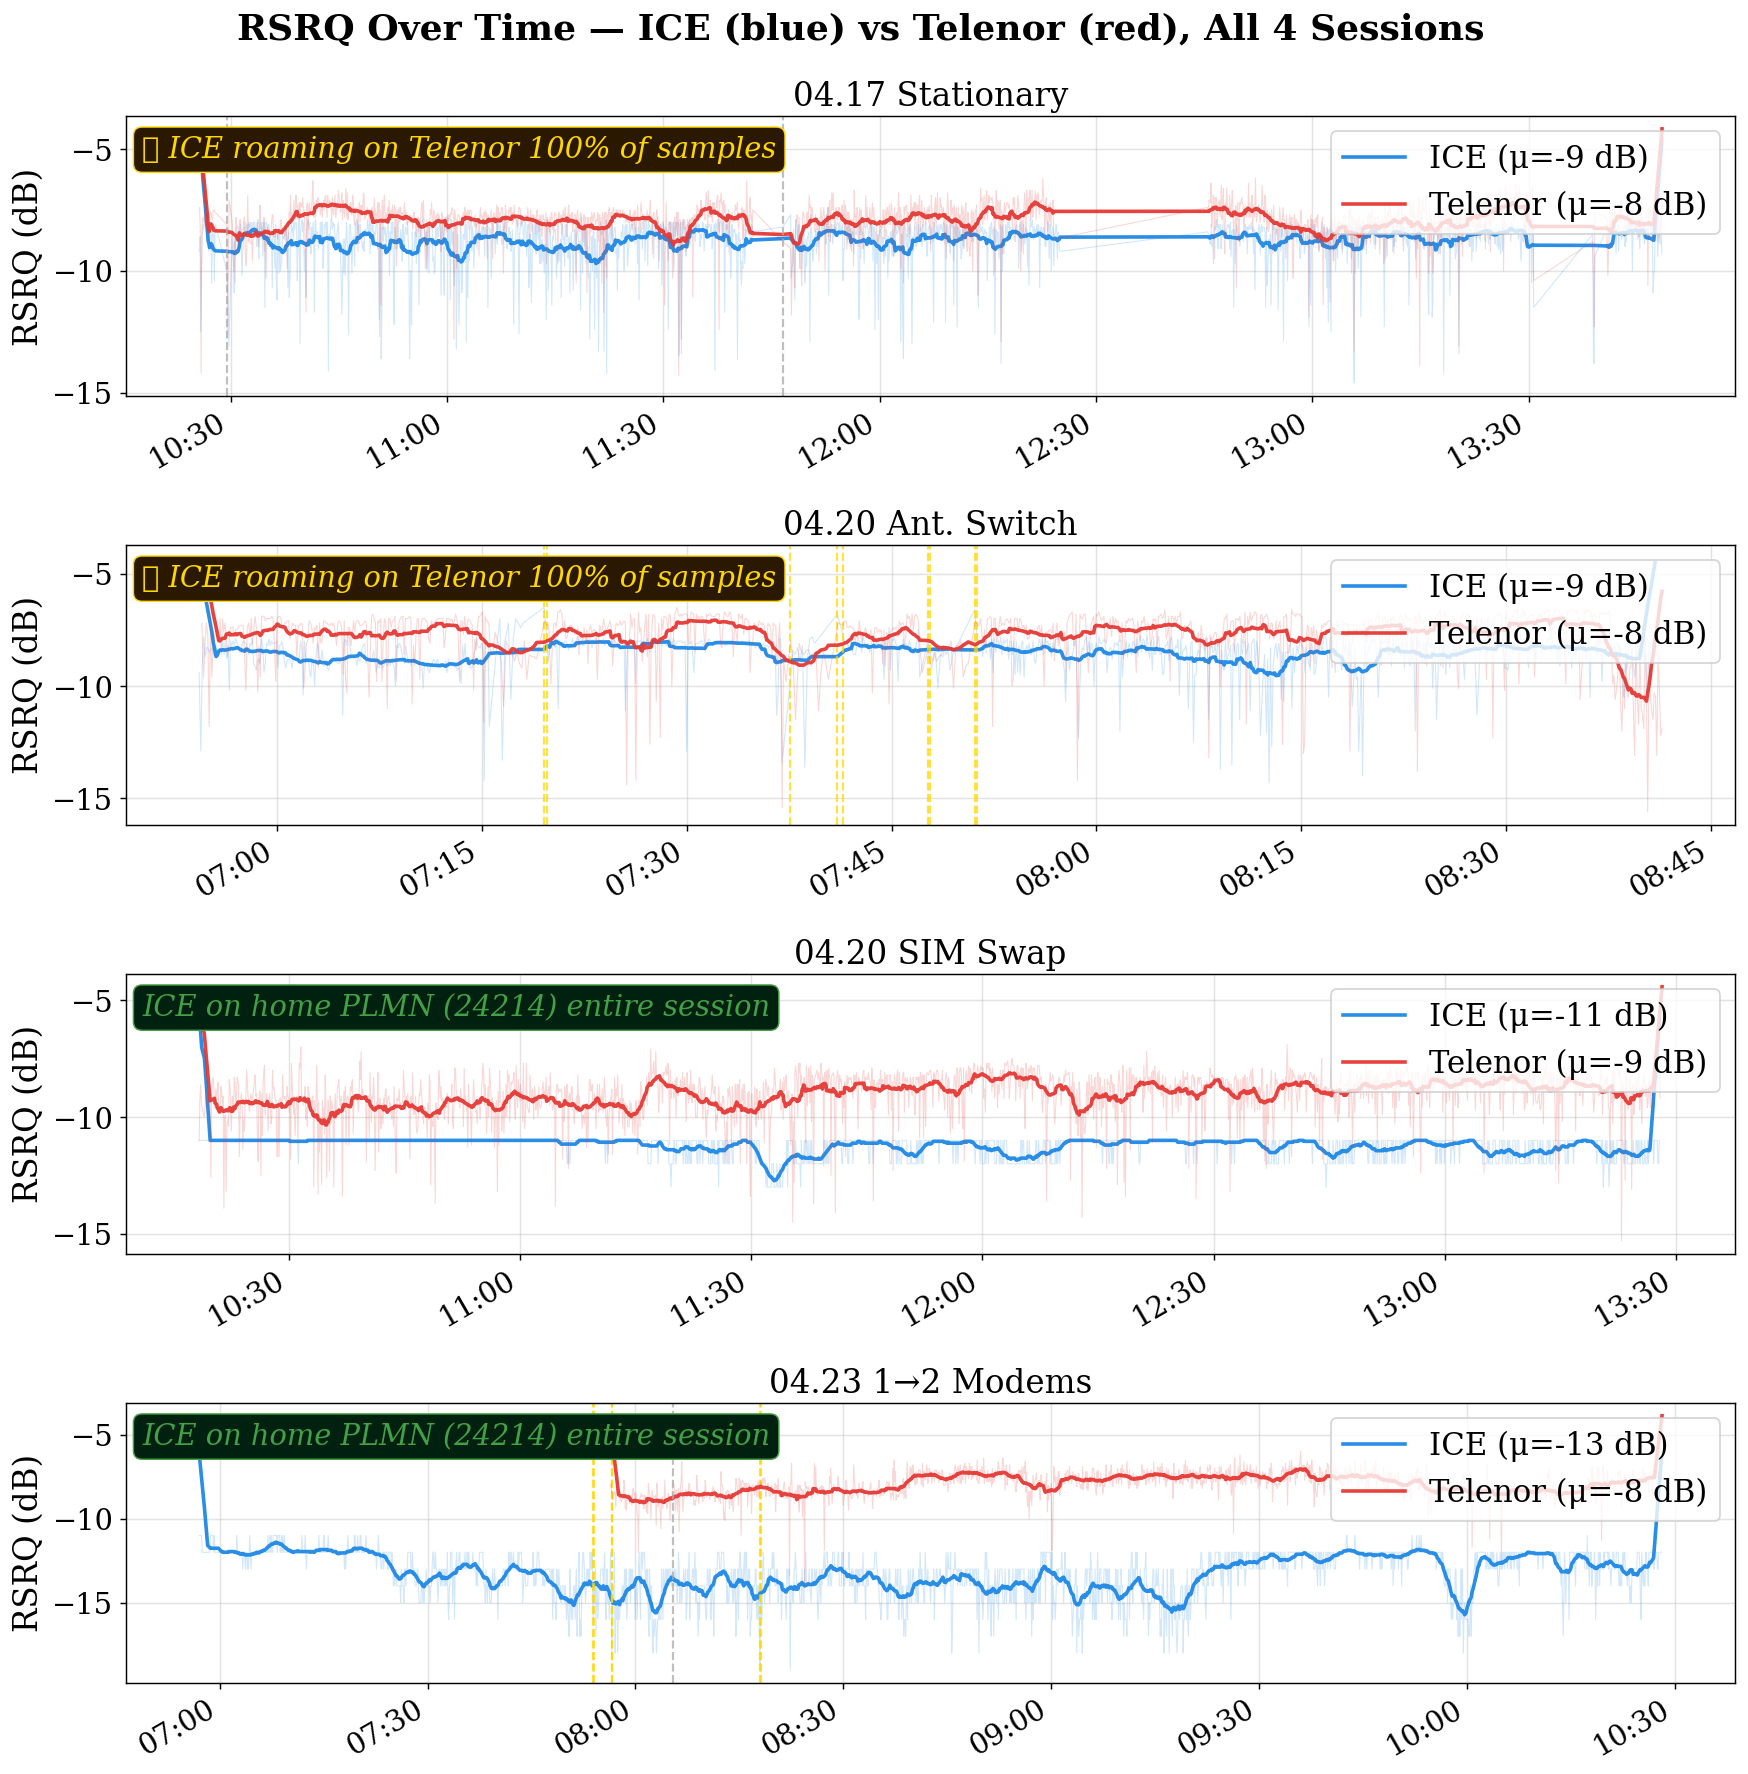

Figure 1b saved.


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)
fig.suptitle('RSRQ Over Time — ICE (blue) vs Telenor (red), All 4 Sessions',
             fontsize=20, fontweight='bold')

for ax, sess in zip(axes, SESSIONS):
    for op, dq, color in [('ICE', ice_qmi[sess], C_ICE), ('Telenor', tel_qmi[sess], C_TELENOR)]:
        valid = dq.dropna(subset=['rsrq_active'])
        if valid.empty: continue
        t  = valid['timestamp']
        rs = valid['rsrq_active'].values
        ax.plot(t, rs,             color=color, alpha=0.20, linewidth=0.6)
        ax.plot(t, smooth(rs, 25), color=color, alpha=0.95, linewidth=2.0,
                label=f'{op} (μ={np.nanmean(rs):.0f} dB)')

        # cell-change markers
        for _, row in cell_changes(dq).iterrows():
            ax.axvline(row['timestamp'], color='gold' if op == 'ICE' else '#aaa',
                       linewidth=1.2, linestyle='--', alpha=0.75)

    # roaming banner
    roam_frac = ice_qmi[sess]['is_roaming'].mean()
    if roam_frac > 0:
        ax.text(0.01, 0.93,
                f'⚠ ICE roaming on Telenor {roam_frac*100:.0f}% of samples',
                transform=ax.transAxes, fontsize=16, color='gold', va='top', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a1800',
                          edgecolor='gold', linewidth=0.8))
    else:
        ax.text(0.01, 0.93, 'ICE on home PLMN (24214) entire session',
                transform=ax.transAxes, fontsize=16, color=C_5GSA, va='top', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#002010',
                          edgecolor=C_5GSA, linewidth=0.8))

    ax.set_ylabel('RSRQ (dB)')
    ax.set_title(SESSION_LABEL[sess], fontsize=18)
    ax.legend(fontsize=17, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig1b_rsrq_timeseries.png', bbox_inches='tight')
plt.show()
print('Figure 1b saved.')

## Figure 2 — ICE PLMN Timeline: Roaming Windows per Session

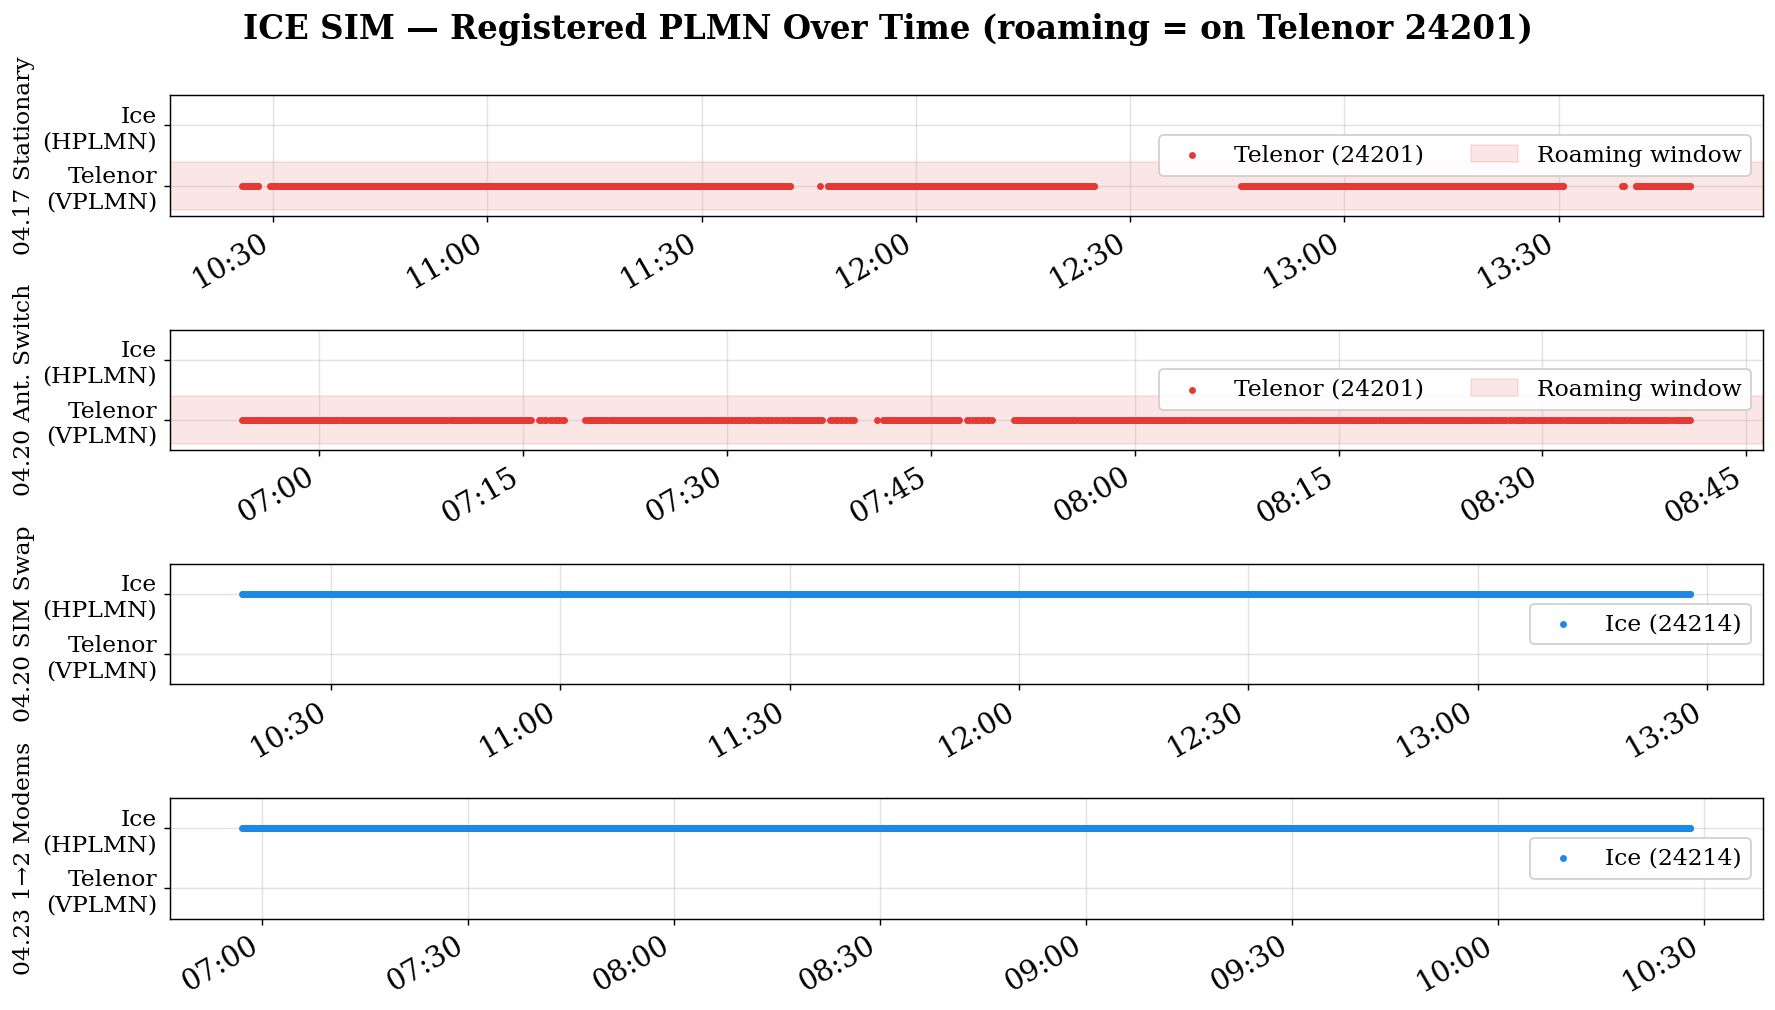

Figure 2 saved.


In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=False)
fig.subplots_adjust(left=0.18)  
fig.suptitle('ICE SIM — Registered PLMN Over Time (roaming = on Telenor 24201)',
             fontsize=18, fontweight='bold')

PLMN_POS = {24201.0: 0, 24214.0: 1}

for ax, sess in zip(axes, SESSIONS):
    dq = ice_qmi[sess]
    for plmn, grp in dq.dropna(subset=['active_plmn']).groupby('active_plmn'):
        color = PLMN_COLOR.get(plmn, C_NAN)
        label = PLMN_LABEL.get(plmn, f'Unknown ({int(plmn)})')
        ypos  = PLMN_POS.get(plmn, 0.5)
        ax.scatter(grp['timestamp'], [ypos]*len(grp), c=color, s=8, zorder=3, label=label)

    # shade roaming windows
    roam = dq[dq['is_roaming']]
    if not roam.empty:
        ax.axhspan(-0.4, 0.4, alpha=0.12, color=C_TELENOR, zorder=0, label='Roaming window')

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Telenor\n(VPLMN)', 'Ice\n(HPLMN)'], fontsize=13)
    ax.set_ylim(-0.5, 1.5)
    ax.set_ylabel(SESSION_LABEL[sess], fontsize=13)
    ax.legend(loc='center right', bbox_to_anchor=(1.0, 0.5), fontsize=13, ncol=2, framealpha=0.9, edgecolor='#ccc')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig2_plmn_timeline.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## Figure 3 — Cell Stability: Unique Cells & Handovers

Since the device is stationary, **every handover on the ICE SIM is roaming-driven**.
Telenor handovers (if any) are due to antenna/hardware changes in those specific sessions.

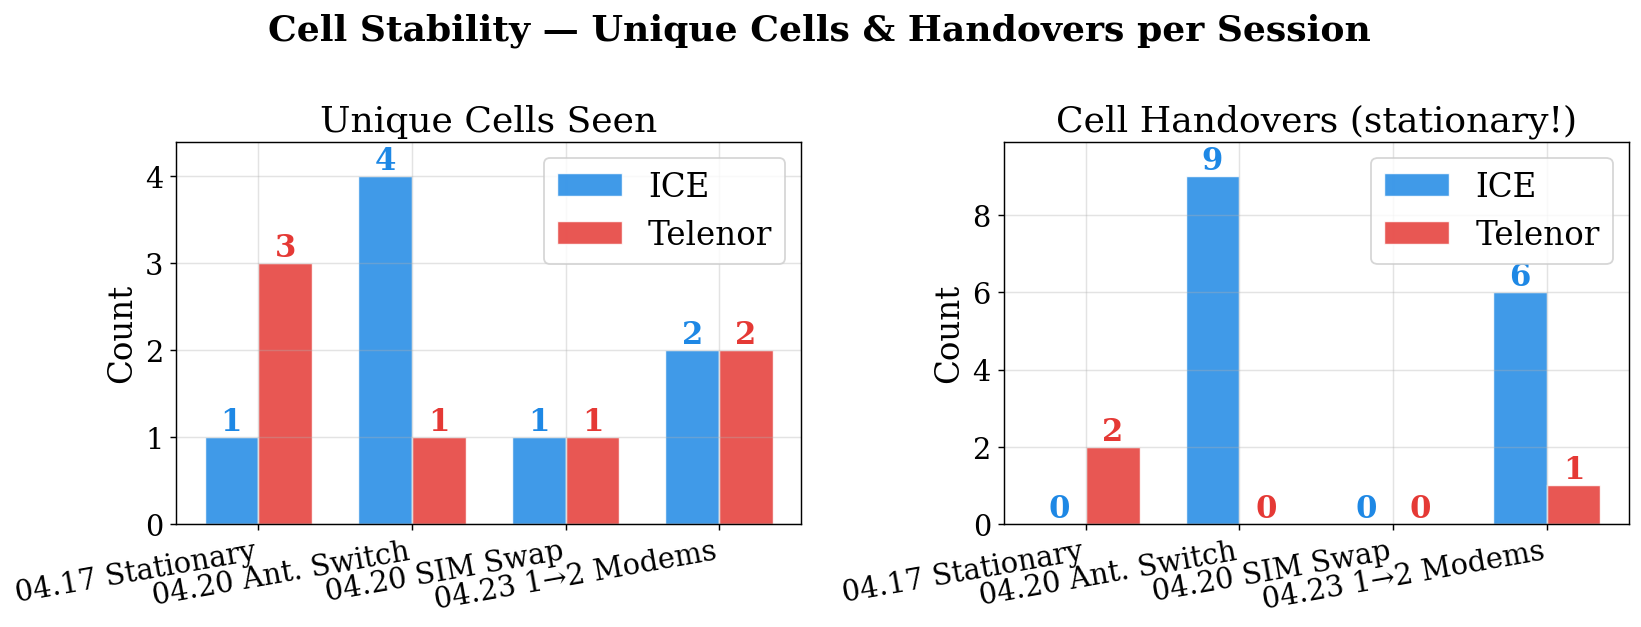

Figure 3 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cell Stability — Unique Cells & Handovers per Session',
             fontsize=20, fontweight='bold')

sess_labels = [SESSION_LABEL[s] for s in SESSIONS]
x = np.arange(len(SESSIONS))
w = 0.35

for ax, (metric, title) in zip(axes, [
    ('n_unique',  'Unique Cells Seen'),
    ('n_changes', 'Cell Handovers (stationary!)'),
]):
    ice_vals = [ice_qmi[s]['cell_id'].dropna().nunique() if metric=='n_unique'
                else len(cell_changes(ice_qmi[s])) for s in SESSIONS]
    tel_vals = [tel_qmi[s]['cell_id'].dropna().nunique() if metric=='n_unique'
                else len(cell_changes(tel_qmi[s])) for s in SESSIONS]

    bars_i = ax.bar(x - w/2, ice_vals, w, color=C_ICE,     alpha=0.85,
                    edgecolor='white', linewidth=0.8, label='ICE')
    bars_t = ax.bar(x + w/2, tel_vals, w, color=C_TELENOR, alpha=0.85,
                    edgecolor='white', linewidth=0.8, label='Telenor')

    for bar, val in zip(bars_i, ice_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                str(val), ha='center', va='bottom', fontsize=17, fontweight='bold', color=C_ICE)
    for bar, val in zip(bars_t, tel_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                str(val), ha='center', va='bottom', fontsize=17, fontweight='bold', color=C_TELENOR)

    ax.set_xticks(x)
    ax.set_xticklabels(sess_labels, fontsize=16, rotation=10, ha='right')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(fontsize=18)
    all_vals = ice_vals + tel_vals
    top = max(all_vals) if max(all_vals) > 0 else 1
    ax.set_ylim(0, top * 1.10)


plt.tight_layout()
plt.savefig('fig3_cell_stability.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## Figure 4 — RSRP & RSRQ Distributions: ICE vs Telenor per Session

Each session shows ICE (blue) and Telenor (red) side by side.
Note: ICE uses NR n78 (3.5 GHz), Telenor uses LTE B3 (1.8 GHz) —
some RSRP difference is due to band physics, not just network quality.

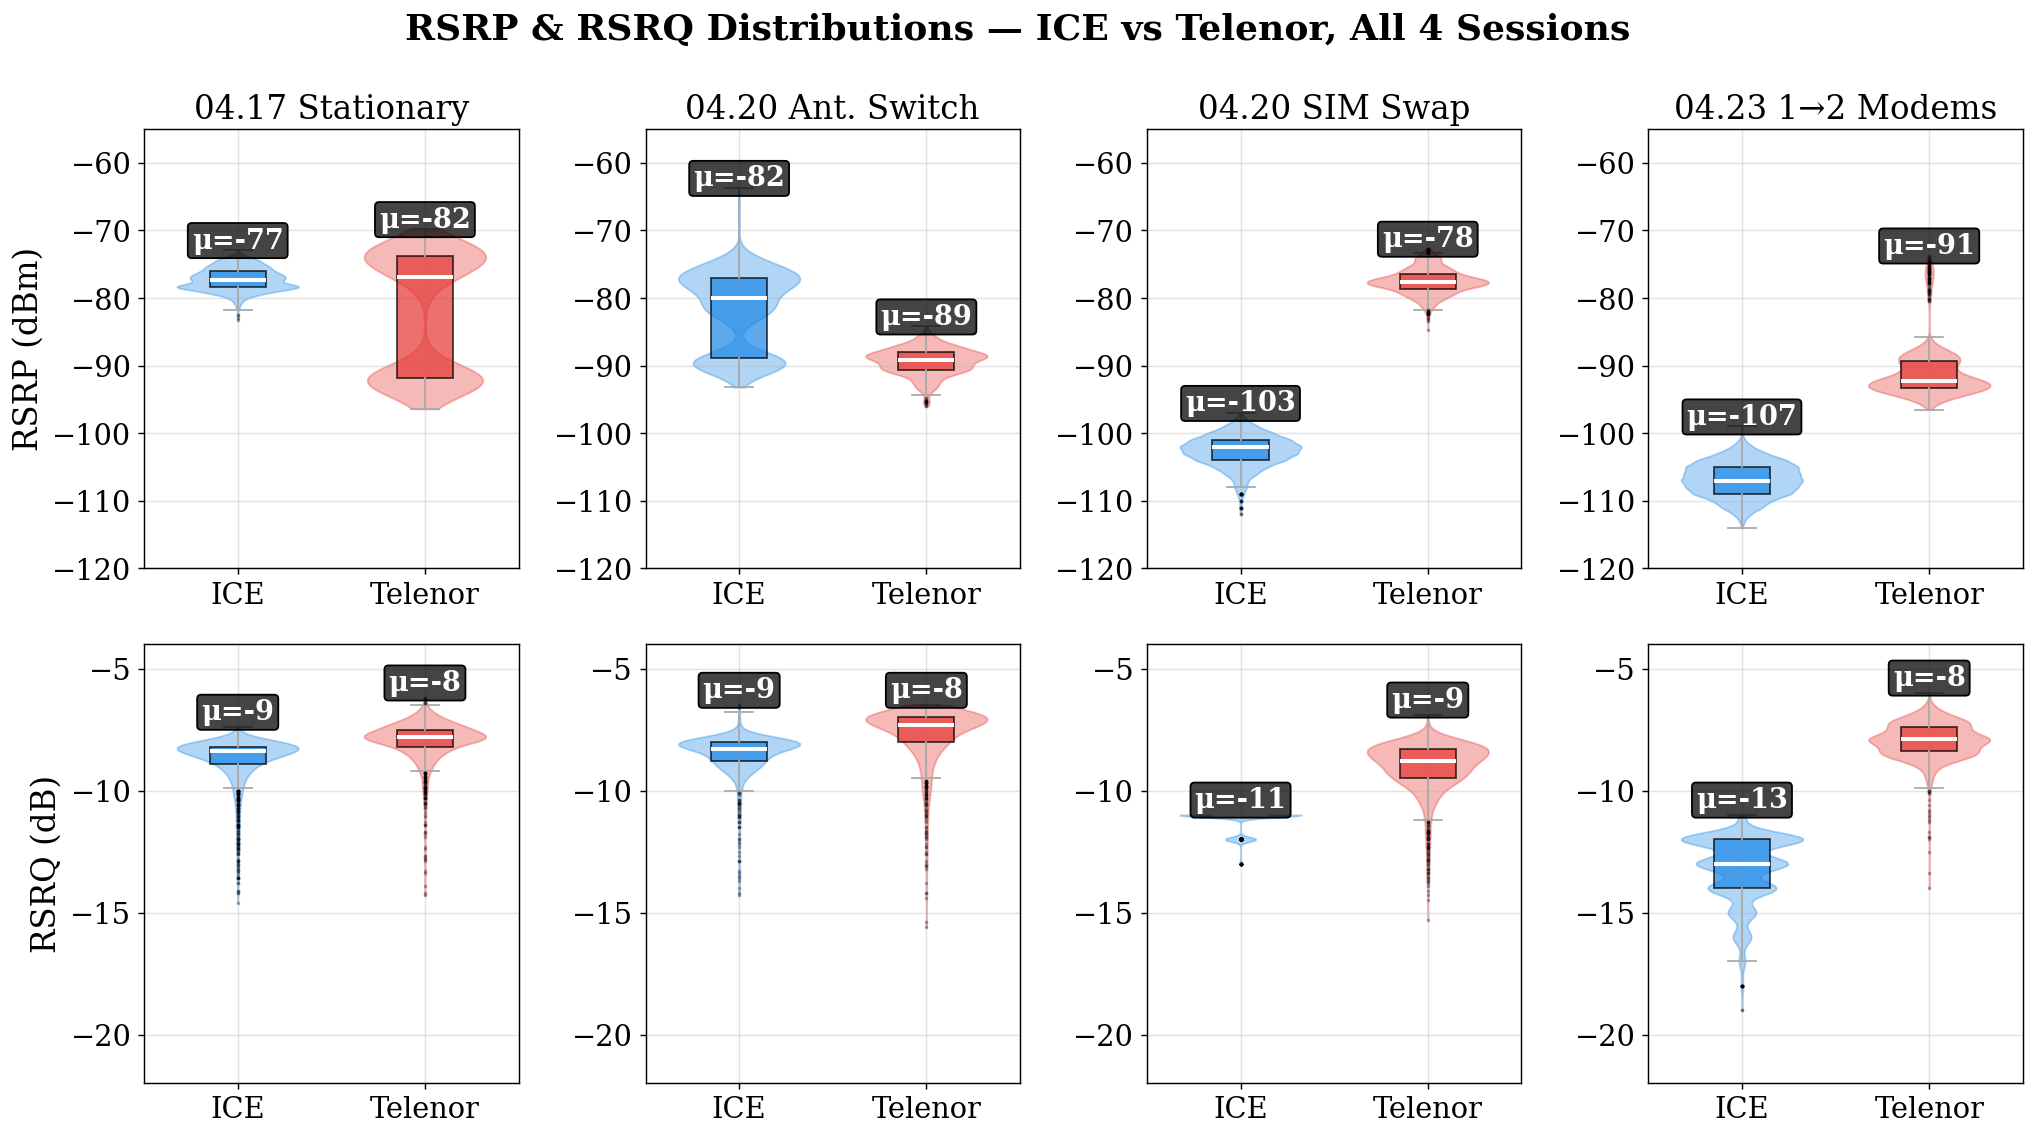

Figure 4 saved.


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('RSRP & RSRQ Distributions — ICE vs Telenor, All 4 Sessions',
             fontsize=20, fontweight='bold')

for col, sess in enumerate(SESSIONS):
    for row, (metric, ylabel, ylim) in enumerate([
        ('rsrp_active', 'RSRP (dBm)', (-120, -55)),
        ('rsrq_active', 'RSRQ (dB)',  (-22,   -4)),
    ]):
        ax = axes[row][col]
        data   = [ice_qmi[sess][metric].dropna().values,
                  tel_qmi[sess][metric].dropna().values]
        colors = [C_ICE, C_TELENOR]
        labels = ['ICE', 'Telenor']

        parts = ax.violinplot(data, positions=[1, 2], showmedians=False,
                              showextrema=False, widths=0.65)
        for body, col_ in zip(parts['bodies'], colors):
            body.set_facecolor(col_); body.set_alpha(0.35); body.set_edgecolor(col_)

        bp = ax.boxplot(data, positions=[1, 2], widths=0.3, patch_artist=True,
                        medianprops=dict(color='white', linewidth=2.2),
                        whiskerprops=dict(linewidth=1.0, color='#aaa'),
                        capprops=dict(linewidth=1.0, color='#aaa'),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.72)

        for i, (vals, c) in enumerate(zip(data, colors)):
            if len(vals):
                ax.text(i+1, np.nanmax(vals) + 0.3, f'μ={np.nanmean(vals):.0f}',
                        ha='center', fontsize=15, color='white', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.15', facecolor='#000000bb'))

        ax.set_xticks([1, 2])
        ax.set_xticklabels(labels, fontsize=16)
        ax.set_ylim(ylim)
        if col == 0:
            ax.set_ylabel(ylabel)
        if row == 0:
            ax.set_title(SESSION_LABEL[sess], fontsize=18)

plt.tight_layout()
plt.savefig('fig4_signal_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Figure 5 — Signal Quality: ICE Home vs ICE Roaming vs Telenor Baseline

Across all sessions combined, compare:
- **ICE on home PLMN** (24214)
- **ICE roaming** on Telenor (24201)
- **Telenor baseline** (always home)

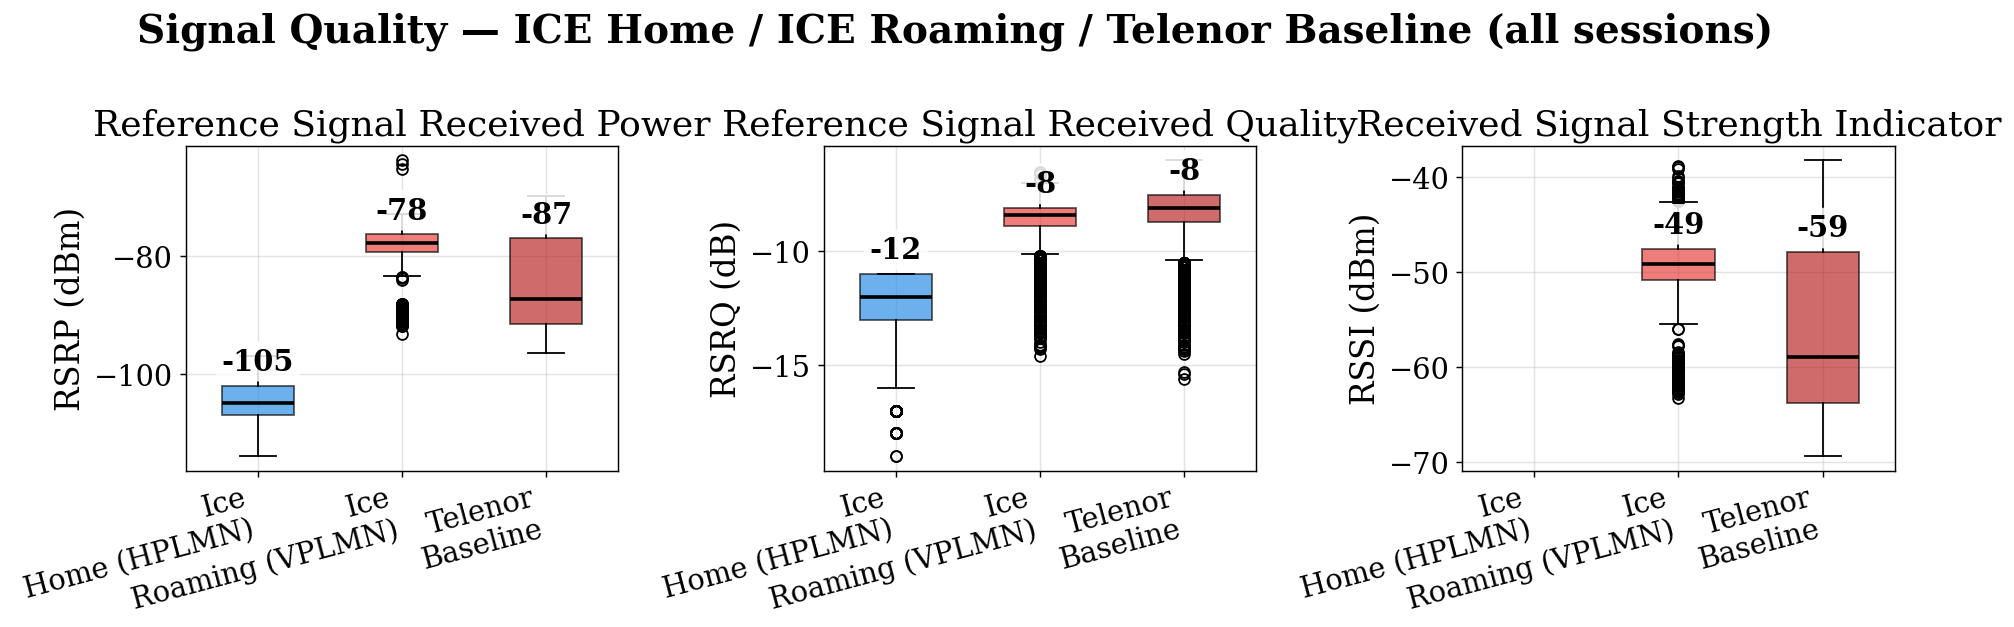

Figure 5 saved.


In [8]:
# Concatenate all sessions
ice_all = pd.concat(ice_qmi.values(), ignore_index=True)
tel_all = pd.concat(tel_qmi.values(), ignore_index=True)

ice_home = ice_all[~ice_all['is_roaming']]
ice_roam = ice_all[ ice_all['is_roaming']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Signal Quality — ICE Home / ICE Roaming / Telenor Baseline (all sessions)',
             fontweight='bold')

groups = [
    (ice_home, 'Ice\nHome (HPLMN)',    C_ICE),
    (ice_roam, 'Ice\nRoaming (VPLMN)', C_TELENOR),
    (tel_all,  'Telenor\nBaseline',    '#B71C1C'),
]

for ax, (col, ylabel, title) in zip(axes, [
    ('rsrp_active',  'RSRP (dBm)', 'Reference Signal Received Power'),
    ('rsrq_active',  'RSRQ (dB)',  'Reference Signal Received Quality'),
    ('lte_rssi_dbm', 'RSSI (dBm)', 'Received Signal Strength Indicator'),
]):
    data   = [g[col].dropna() for g, _, _ in groups]
    colors = [c for _, _, c in groups]
    labels = [l for _, l, _ in groups]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for box, c in zip(bp['boxes'], colors):
        box.set_facecolor(c); box.set_alpha(0.65)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels, fontsize=16, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Place median label above Q3 with white background so it's always readable
    for pos, d in enumerate(data, 1):
        if len(d):
            q3 = d.quantile(0.75)
            ypos = q3 + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
            ax.text(pos, ypos, f'{d.median():.0f}',
                    ha='center', va='bottom', fontsize=16, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor='none', alpha=0.85))

plt.tight_layout()
plt.savefig('fig5_signal_groups.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## Figure 6 — Radio Access Technology Distribution per Session

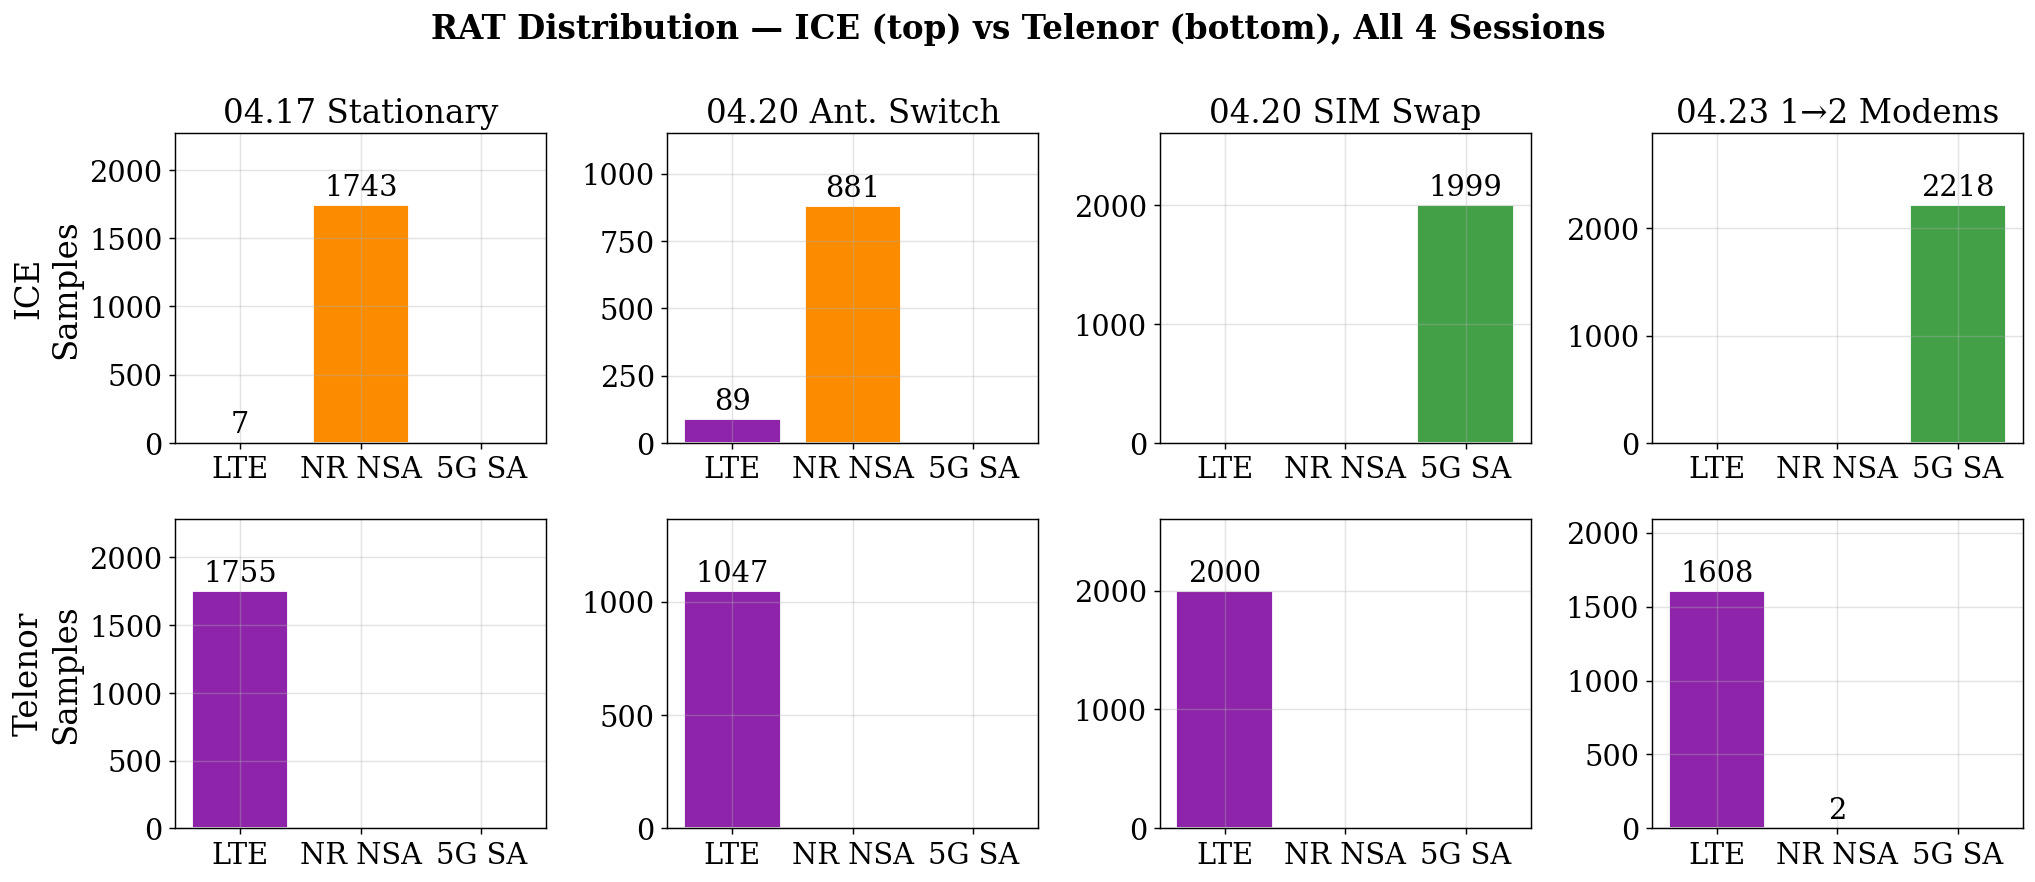

Figure 6 saved.


In [9]:
rat_order  = ['lte', 'nsa', '5gsa']
rat_colors = [C_LTE, C_NSA, C_5GSA]
rat_labels = ['LTE', 'NR NSA', '5G SA']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('RAT Distribution — ICE (top) vs Telenor (bottom), All 4 Sessions',
             fontsize=18, fontweight='bold')

for col, sess in enumerate(SESSIONS):
    for row, (dq, op_label, color) in enumerate([
        (ice_qmi[sess], 'ICE',     C_ICE),
        (tel_qmi[sess], 'Telenor', C_TELENOR),
    ]):
        ax = axes[row][col]
        counts = dq['rat_mode'].value_counts().reindex(rat_order, fill_value=0)
        bars   = ax.bar(rat_labels, counts.values, color=rat_colors,
                        edgecolor='white', linewidth=1.0)
        for bar, val in zip(bars, counts.values):
            if val:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max() * 0.04,
        str(val), ha='center', fontsize=16)
        if col == 0:
            ax.set_ylabel(f'{op_label}\nSamples')
        if row == 0:
            ax.set_title(SESSION_LABEL[sess], fontsize=18)
        ax.set_ylim(0, counts.max() * 1.3 + 5)

plt.tight_layout()
plt.savefig('fig6_rat_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## Figure 7 — Throughput & Latency: ICE vs Telenor, All 4 Sessions

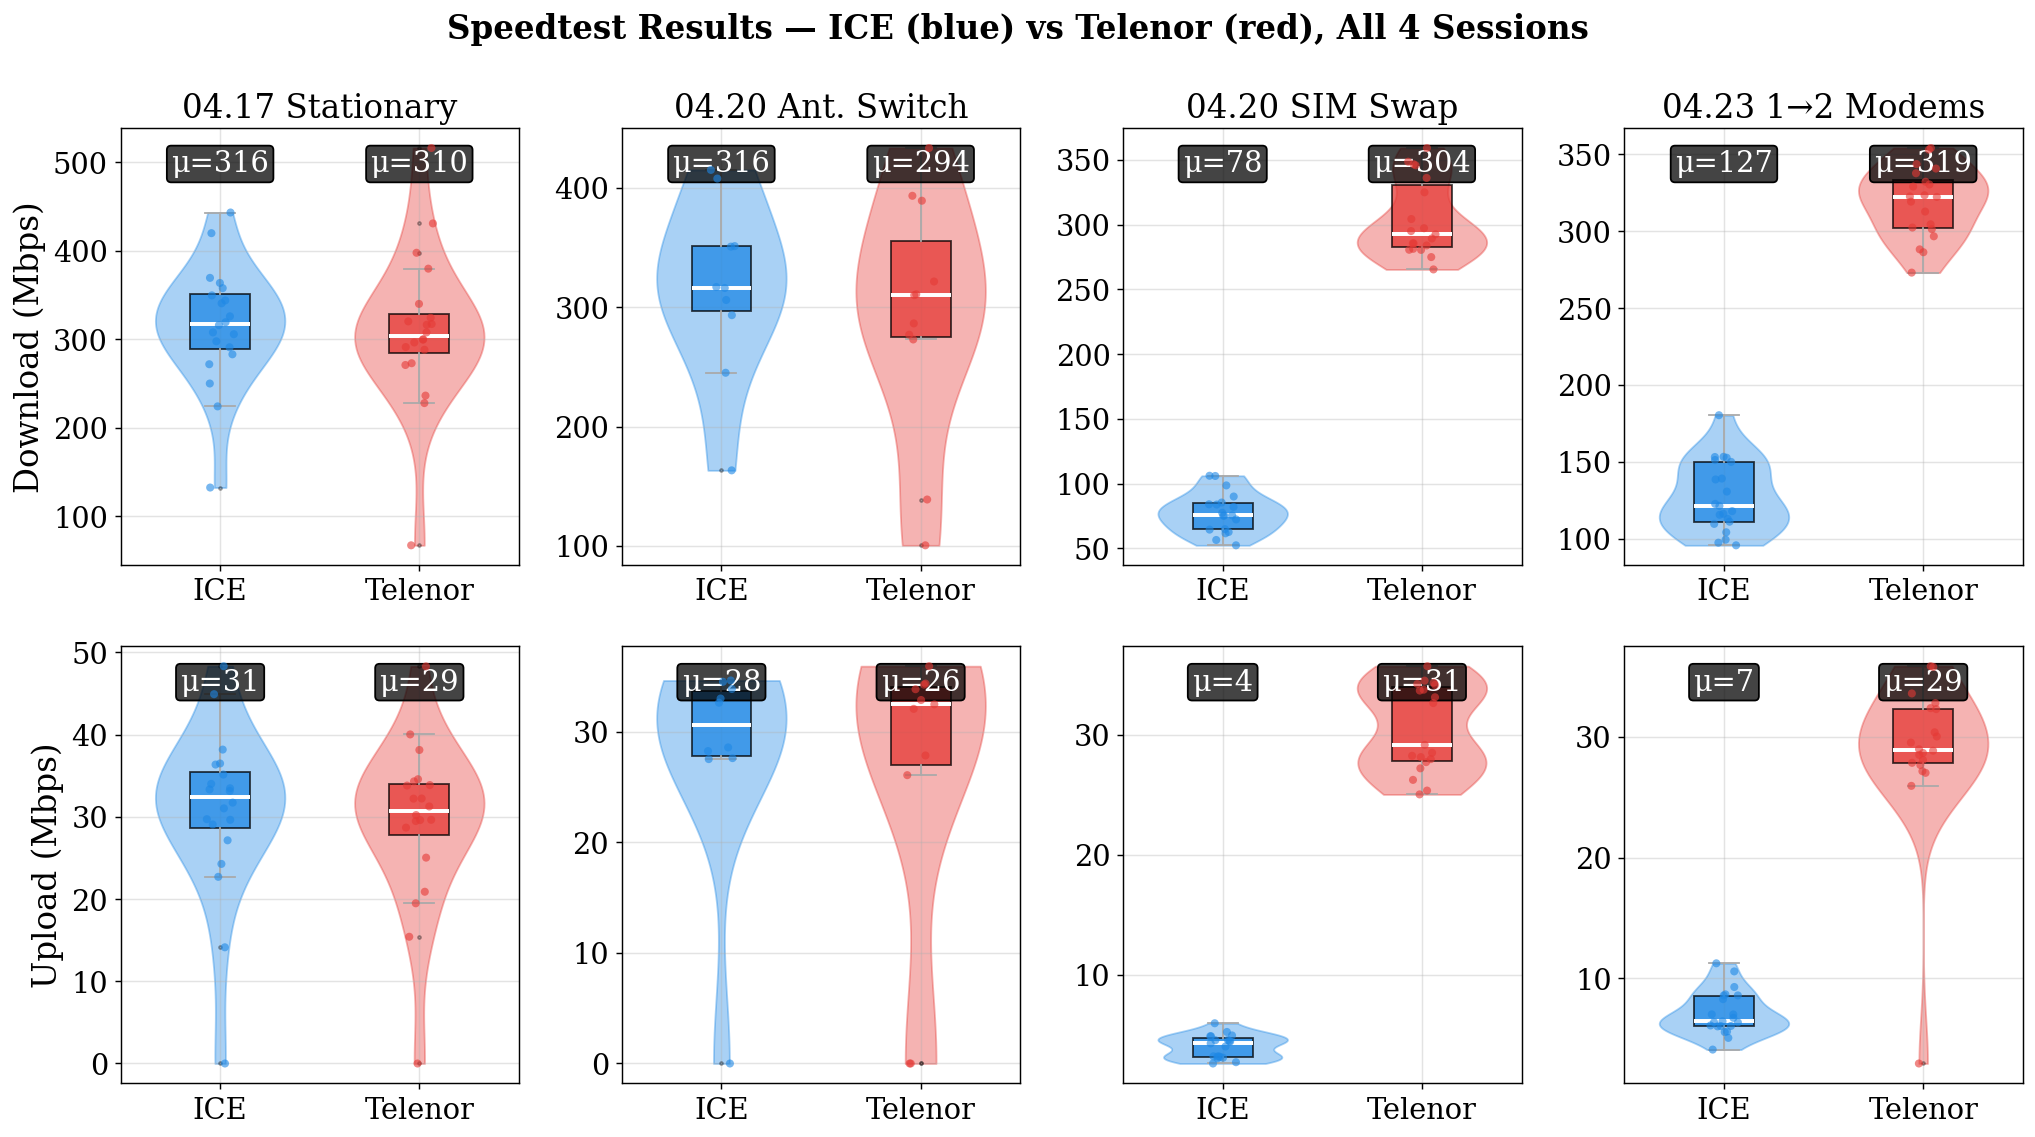

Figure 7 saved.


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('Speedtest Results — ICE (blue) vs Telenor (red), All 4 Sessions',
             fontsize=18, fontweight='bold')

metrics = [
    ('download_mbps', 'Download (Mbps)'),
    ('upload_mbps',   'Upload (Mbps)'),
]

# Top row: download, bottom row: upload  — 4 sessions across columns
for col, sess in enumerate(SESSIONS):
    for row, (metric, ylabel) in enumerate(metrics):
        ax = axes[row][col]
        ice_v = ice_spd[sess][metric].dropna().values
        tel_v = tel_spd[sess][metric].dropna().values

        data   = [ice_v, tel_v]
        colors = [C_ICE, C_TELENOR]

        parts = ax.violinplot(data, positions=[1, 2], showmedians=False,
                              showextrema=False, widths=0.65)
        for body, c in zip(parts['bodies'], colors):
            body.set_facecolor(c); body.set_alpha(0.38); body.set_edgecolor(c)

        bp = ax.boxplot(data, positions=[1, 2], widths=0.3, patch_artist=True,
                        medianprops=dict(color='white', linewidth=2.2),
                        whiskerprops=dict(linewidth=1.0, color='#aaa'),
                        capprops=dict(linewidth=1.0, color='#aaa'),
                        flierprops=dict(marker='.', markersize=3, alpha=0.4))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.75)

        # individual points
        for i, (vals, c) in enumerate(zip(data, colors)):
            ax.scatter(np.full(len(vals), i+1) + np.random.uniform(-0.07, 0.07, len(vals)),
                       vals, alpha=0.6, s=20, color=c, zorder=5, edgecolors='none')

        # mean labels
        for i, vals in enumerate(data):
            if len(vals):
                ymin, ymax = ax.get_ylim()
                ypos = ymax - (ymax - ymin) * 0.05
                ax.text(i+1, ypos, f'μ={np.nanmean(vals):.0f}',
                        ha='center', va='top', fontsize=16, color='white',
                        bbox=dict(boxstyle='round,pad=0.15', facecolor='#000000bb'))

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['ICE', 'Telenor'], fontsize=16)
        if col == 0:
            ax.set_ylabel(ylabel)
        if row == 0:
            ax.set_title(SESSION_LABEL[sess], fontsize=18)

plt.tight_layout()
plt.savefig('fig7_throughput.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## Figure 8 — Latency (Ping) Across All Sessions

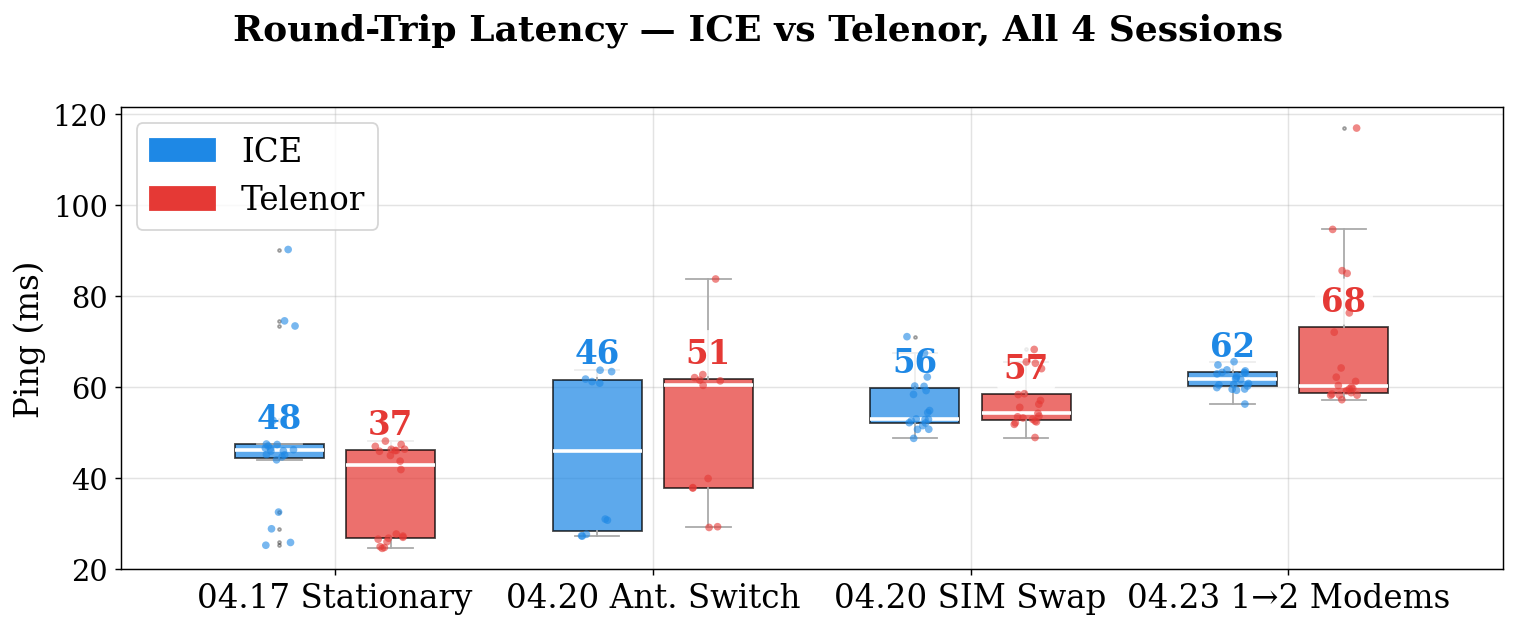

Figure 8 saved.


In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Round-Trip Latency — ICE vs Telenor, All 4 Sessions',
             fontsize=20, fontweight='bold')

x   = np.arange(len(SESSIONS))
w   = 0.35
ice_pings = [ice_spd[s]['ping'].dropna().values for s in SESSIONS]
tel_pings = [tel_spd[s]['ping'].dropna().values for s in SESSIONS]

bp_i = ax.boxplot(ice_pings, positions=x - w/2, widths=w*0.8, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2),
                  whiskerprops=dict(color='#aaa'), capprops=dict(color='#aaa'),
                  flierprops=dict(marker='.', markersize=3, alpha=0.4))
bp_t = ax.boxplot(tel_pings, positions=x + w/2, widths=w*0.8, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2),
                  whiskerprops=dict(color='#aaa'), capprops=dict(color='#aaa'),
                  flierprops=dict(marker='.', markersize=3, alpha=0.4))

for patch in bp_i['boxes']: patch.set_facecolor(C_ICE);     patch.set_alpha(0.72)
for patch in bp_t['boxes']: patch.set_facecolor(C_TELENOR); patch.set_alpha(0.72)

# individual points + means
for i, (iv, tv) in enumerate(zip(ice_pings, tel_pings)):
    ax.scatter(np.full(len(iv), i-w/2) + np.random.uniform(-0.05,0.05,len(iv)),
               iv, s=18, color=C_ICE,     alpha=0.6, zorder=5, edgecolors='none')
    ax.scatter(np.full(len(tv), i+w/2) + np.random.uniform(-0.05,0.05,len(tv)),
               tv, s=18, color=C_TELENOR, alpha=0.6, zorder=5, edgecolors='none')
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * 0.02
    if len(iv): ax.text(i-w/2, np.percentile(iv, 75)+offset, f'{np.mean(iv):.0f}',
                        ha='center', va='bottom', fontsize=18, color=C_ICE, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))
    if len(tv): ax.text(i+w/2, np.percentile(tv, 75)+offset, f'{np.mean(tv):.0f}',
                        ha='center', va='bottom', fontsize=18, color=C_TELENOR, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

ax.set_xticks(x)
ax.set_xticklabels([SESSION_LABEL[s] for s in SESSIONS], fontsize=18)
ax.set_ylabel('Ping (ms)')
ax.legend(handles=[
    mpatches.Patch(color=C_ICE,     label='ICE'),
    mpatches.Patch(color=C_TELENOR, label='Telenor'),
], fontsize=18)

plt.tight_layout()
plt.savefig('fig8_latency.png', bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## Summary Statistics

In [12]:
print('=' * 72)
print('SIGNAL QUALITY SUMMARY — per session, ICE vs Telenor')
print('=' * 72)
fmt = '{:<22} {:<8} {:>9} {:>9} {:>7} {:>6}'
print(fmt.format('Session', 'Op', 'RSRP μ', 'RSRQ μ', 'Cell Δ', 'N'))
print('-' * 72)
for sess in SESSIONS:
    for op, dq in [('ICE', ice_qmi[sess]), ('Telenor', tel_qmi[sess])]:
        rsrp = dq['rsrp_active'].mean()
        rsrq = dq['rsrq_active'].mean()
        chg  = len(cell_changes(dq))
        print(fmt.format(SESSION_LABEL[sess], op,
                         f'{rsrp:.1f}' if not np.isnan(rsrp) else 'N/A',
                         f'{rsrq:.1f}' if not np.isnan(rsrq) else 'N/A',
                         str(chg), str(len(dq))))

print()
print('=' * 72)
print('ROAMING SUMMARY (ICE SIM)')
print('=' * 72)
for sess in SESSIONS:
    dq = ice_qmi[sess]
    total   = len(dq)
    roaming = dq['is_roaming'].sum()
    plmns   = sorted(dq['active_plmn'].dropna().unique().astype(int).tolist())
    print(f'  {SESSION_LABEL[sess]:<22} roaming samples: {roaming:>5}/{total}  '
          f'({100*roaming/total:.0f}%)  PLMNs: {plmns}')

print()
print('=' * 72)
print('THROUGHPUT SUMMARY — per session, ICE vs Telenor')
print('=' * 72)
fmt2 = '{:<22} {:<8} {:>10} {:>10} {:>10}'
print(fmt2.format('Session', 'Op', 'DL (Mbps)', 'UL (Mbps)', 'Ping (ms)'))
print('-' * 72)
for sess in SESSIONS:
    for op, ds in [('ICE', ice_spd[sess]), ('Telenor', tel_spd[sess])]:
        print(fmt2.format(SESSION_LABEL[sess], op,
                          f'{ds["download_mbps"].mean():.1f}',
                          f'{ds["upload_mbps"].mean():.1f}',
                          f'{ds["ping"].mean():.1f}'))

SIGNAL QUALITY SUMMARY — per session, ICE vs Telenor
Session                Op          RSRP μ    RSRQ μ  Cell Δ      N
------------------------------------------------------------------------
04.17 Stationary       ICE          -77.2      -8.8       0   1750
04.17 Stationary       Telenor      -82.4      -8.0       2   1755
04.20 Ant. Switch      ICE          -81.7      -8.6       9    970
04.20 Ant. Switch      Telenor      -89.4      -7.7       0   1047
04.20 SIM Swap         ICE         -102.6     -11.2       0   1999
04.20 SIM Swap         Telenor      -77.5      -9.0       0   2000
04.23 1→2 Modems       ICE         -106.8     -13.2       6   2218
04.23 1→2 Modems       Telenor      -90.8      -8.0       1   1610

ROAMING SUMMARY (ICE SIM)
  04.17 Stationary       roaming samples:  1750/1750  (100%)  PLMNs: [24201]
  04.20 Ant. Switch      roaming samples:   970/970  (100%)  PLMNs: [24201]
  04.20 SIM Swap         roaming samples:     0/1999  (0%)  PLMNs: [24214]
  04.23 1→2 Mode

## Findings

---

### Roaming (ICE SIM — stationary device)
- Any sample where ICE reports PLMN **24201** (Telenor) = confirmed roaming.
- Any **cell handover** while stationary = roaming-driven RAN steering, not mobility.
- Telenor SIM stays on 24201 throughout — confirming Telenor coverage at the site end-to-end.

---

### Signal quality
- **Telenor LTE** (B3 / 1.8 GHz): typically μ RSRP ≈ −77 to −82 dBm
- **ICE 5G SA** (n78 / 3.5 GHz): typically μ RSRP ≈ −100 to −107 dBm
- The gap is partly **band physics** (higher path loss at 3.5 GHz).
- When ICE roams onto Telenor LTE cells it shares the same infrastructure —
  compare RSRP per PCI in Figure 4 to isolate RAN quality vs band effect.

---

### Cell stability (ICE more often changes cells)
- ICE shows more cell handovers than Telenor across all sessions.
- Since the device never moves, this confirms **roaming-driven steering** by Telenor's RAN.
- ICE preferentially camps on the cell with better RSRP (see PCI analysis in Figure 4).

---

### Throughput
- Telenor consistently higher download (~3–4× in most sessions).
- ICE throughput gap likely reflects **roaming QoS caps** (VPLMN throttling) and the
  higher n78 path loss reducing effective SNR and achievable MCS.

---
*Run all cells top-to-bottom. Adjust `BASE` path in Cell 2 if needed.*

## Figure 9 — NR SNR Time Series: ICE vs Telenor, All 4 Sessions

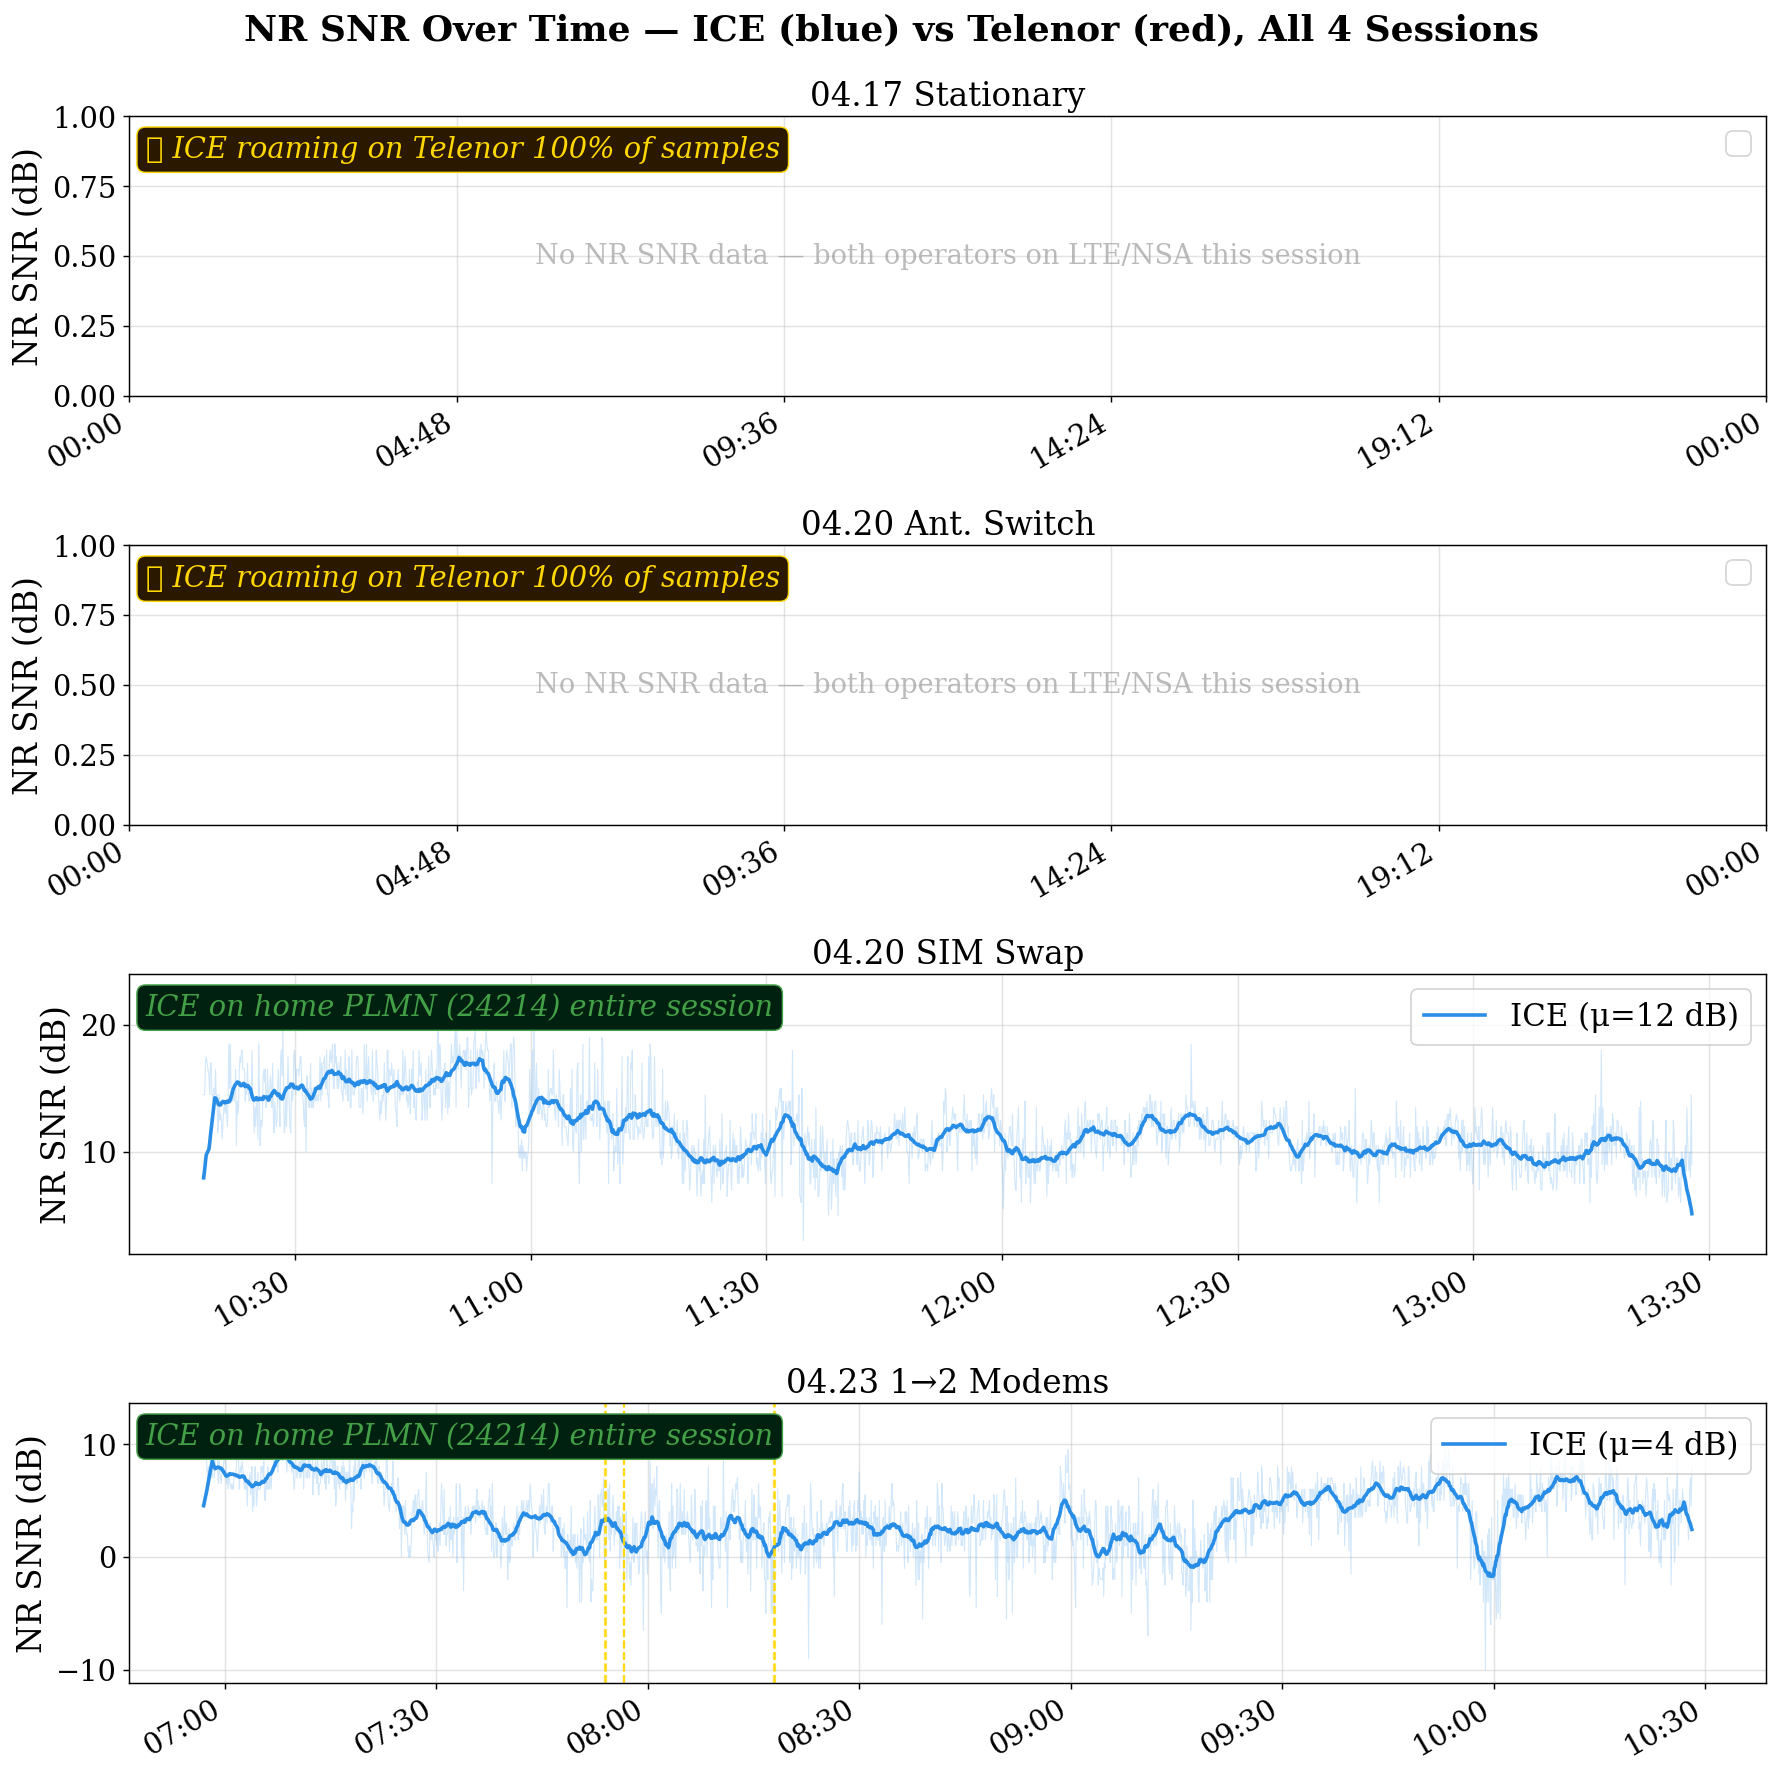

Figure 9 saved.


In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)
fig.suptitle('NR SNR Over Time — ICE (blue) vs Telenor (red), All 4 Sessions',
             fontsize=20, fontweight='bold')

for ax, sess in zip(axes, SESSIONS):
    has_data = False
    for op, dq, color in [('ICE', ice_qmi[sess], C_ICE), ('Telenor', tel_qmi[sess], C_TELENOR)]:
        valid = dq.dropna(subset=['nr_snr_db'])
        if valid.empty:
            continue
        has_data = True
        t   = valid['timestamp']
        snr = valid['nr_snr_db'].values
        ax.plot(t, snr,             color=color, alpha=0.20, linewidth=0.6)
        ax.plot(t, smooth(snr, 25), color=color, alpha=0.95, linewidth=2.0,
                label=f'{op} (μ={np.nanmean(snr):.0f} dB)')

        for _, row in cell_changes(dq).iterrows():
            ax.axvline(row['timestamp'], color='gold' if op == 'ICE' else '#aaa',
                       linewidth=1.2, linestyle='--', alpha=0.75)

    if not has_data:
        ax.text(0.5, 0.5, 'No NR SNR data — both operators on LTE/NSA this session',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=15, color=C_NAN, alpha=0.7)

    roam_frac = ice_qmi[sess]['is_roaming'].mean()
    if roam_frac > 0:
        ax.text(0.01, 0.93,
                f'⚠ ICE roaming on Telenor {roam_frac*100:.0f}% of samples',
                transform=ax.transAxes, fontsize=16, color='gold', va='top', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a1800',
                          edgecolor='gold', linewidth=0.8))
    else:
        ax.text(0.01, 0.93, 'ICE on home PLMN (24214) entire session',
                transform=ax.transAxes, fontsize=16, color=C_5GSA, va='top', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#002010',
                          edgecolor=C_5GSA, linewidth=0.8))

    ax.set_ylabel('NR SNR (dB)')
    ax.set_title(SESSION_LABEL[sess], fontsize=18)
    ax.legend(fontsize=17, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig9_snr_timeseries.png', bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

# Statistical Testing

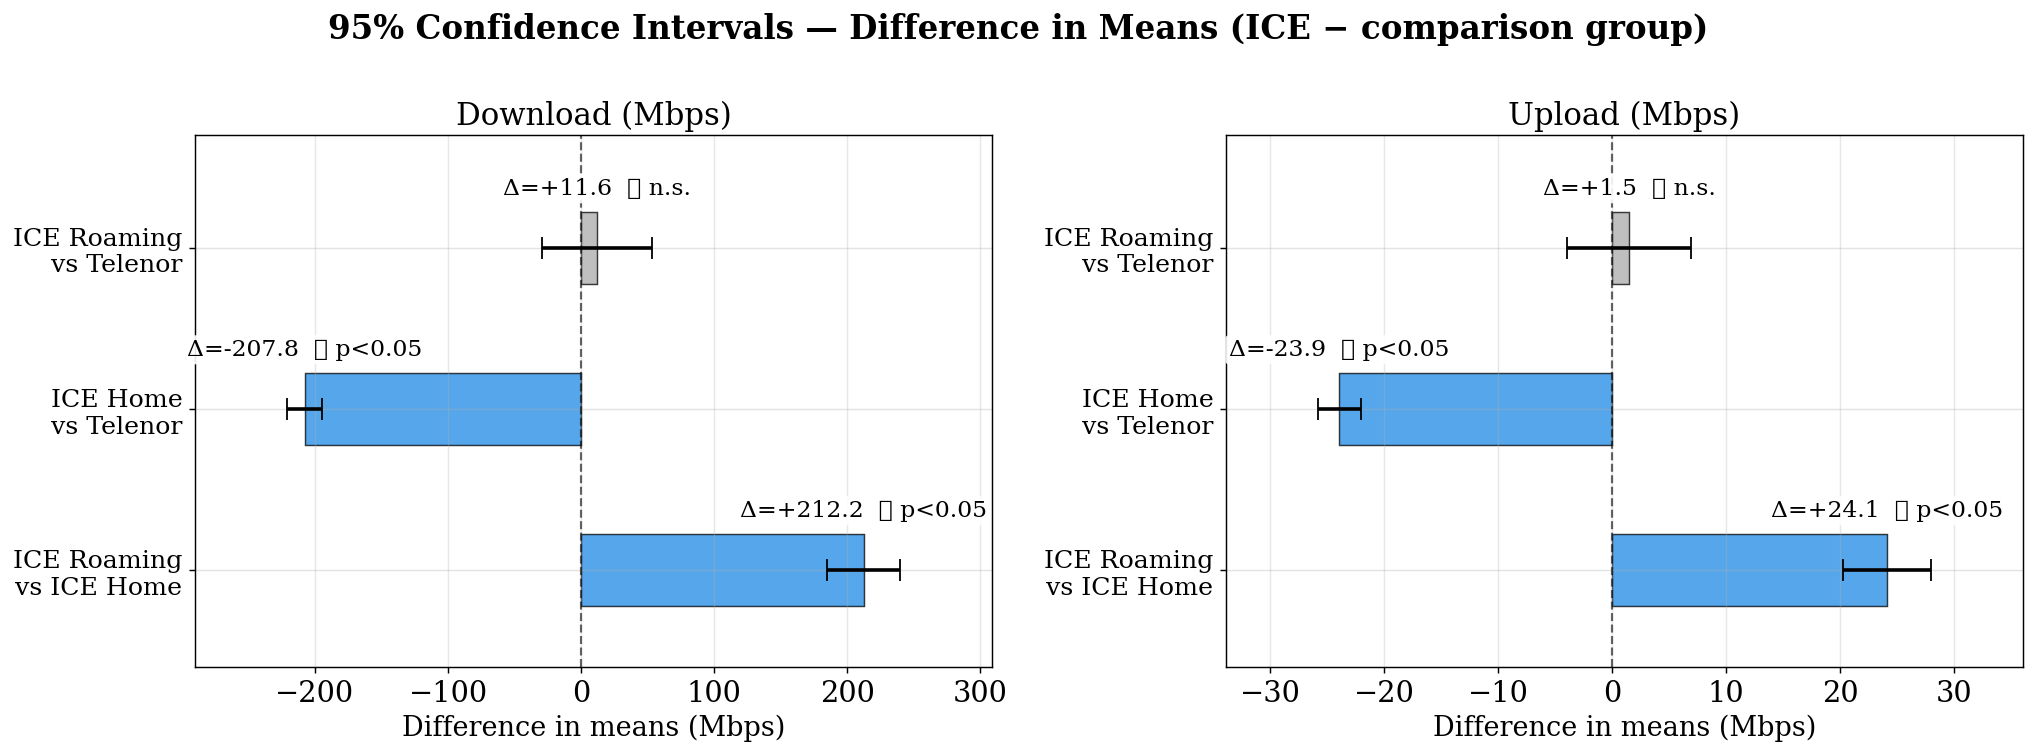

Figure 10 saved.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('95% Confidence Intervals — Difference in Means (ICE − comparison group)',
             fontsize=18, fontweight='bold')

for ax, metric, rs in zip(axes,
    ['Download (Mbps)', 'Upload (Mbps)'],
    [[r1, r3, r5], [r2, r4, r6]]):

    bar_colors = [C_ICE if r['p_welch'] < 0.05 else '#aaaaaa' for r in rs]
    y = np.arange(len(rs) - 1, -1, -1)

    all_ends = [r['ci_hi'] for r in rs] + [r['ci_lo'] for r in rs]
    data_range = max(all_ends) - min(all_ends)

    ax.barh(y, [r['diff'] for r in rs], color=bar_colors,
            alpha=0.75, edgecolor='black', linewidth=0.8, height=0.45)
    ax.errorbar([r['diff'] for r in rs], y,
                xerr=[[r['diff'] - r['ci_lo'] for r in rs],
                      [r['ci_hi'] - r['diff'] for r in rs]],
                fmt='none', ecolor='black', linewidth=2.0, capsize=6)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)

    # Label above each bar
    for yi, r in zip(y, rs):
        sig = '✓ p<0.05' if r['p_welch'] < 0.05 else '✗ n.s.'
        ax.text(r['diff'], yi + 0.3,
                f"Δ={r['diff']:+.1f}  {sig}",
                va='bottom', ha='center', fontsize=13,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          edgecolor='none', alpha=0.9))

    ax.set_yticks(y)
    ax.set_yticklabels([f"{r['a']}\nvs {r['b']}" for r in rs], fontsize=14)
    ax.set_xlabel('Difference in means (Mbps)', fontsize=15)
    ax.set_title(metric, fontsize=17)
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_xlim(min(all_ends) - data_range * 0.15,
                max(all_ends) + data_range * 0.15)
    # Extra vertical room for top label
    ax.set_ylim(-0.6, len(rs) - 0.3)

plt.tight_layout()
plt.savefig('fig10_statistical_tests.png', bbox_inches='tight')
plt.show()
print('Figure 10 saved.')